In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/user/Desktop/python workspace/people.xls - people.xls.csv")

In [4]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [5]:
# Do a basic analysis
df.shape

(14999, 10)

In [7]:
# Rename the last evaluation to performance
df.rename(columns={"lastEvaluation":"Performance"},inplace =True)

In [8]:
df

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   Performance            14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [10]:
df.describe()

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [11]:
df.isnull().sum() # Count of null values per column

satisfactoryLevel        0
Performance              0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [12]:
df.isnull().sum().sum() # count of null values in the enitre dataset

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(3008)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(11991, 10)

In [16]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows) # if u want to look at the duplicate records

Empty DataFrame
Columns: [satisfactoryLevel, Performance, numberOfProjects, avgMonthlyHours, timeSpent.company, workAccident, left, promotionInLast5years, dept, salary]
Index: []


In [17]:
df["salary"].value_counts()

salary
low       5740
medium    5261
high       990
Name: count, dtype: int64

In [18]:
df["dept"].value_counts()

dept
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

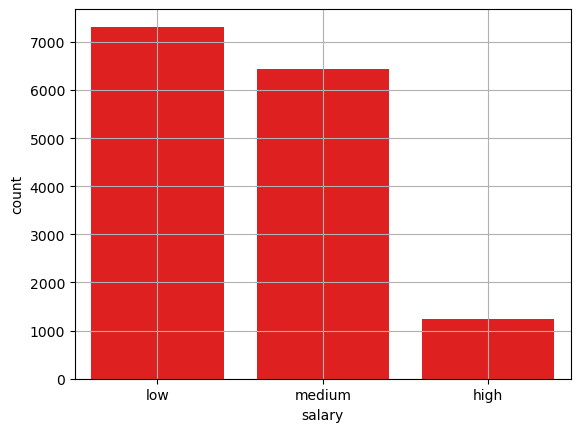

In [10]:
sns.countplot(data=df,x="salary",color="red")
plt.grid()
plt.show()

In [19]:
# Find out if there is a relationship between the no. of projects and the employees who left(left)
df['numberOfProjects'].value_counts()

numberOfProjects
4    3685
3    3520
5    2233
2    1582
6     826
7     145
Name: count, dtype: int64

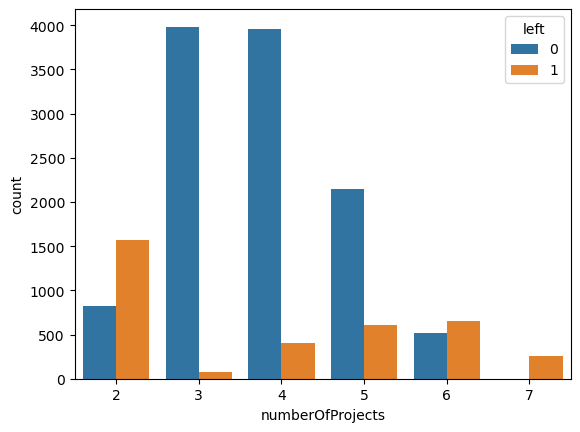

In [8]:
sns.countplot(df, x = "numberOfProjects", hue = "left")
plt.show()

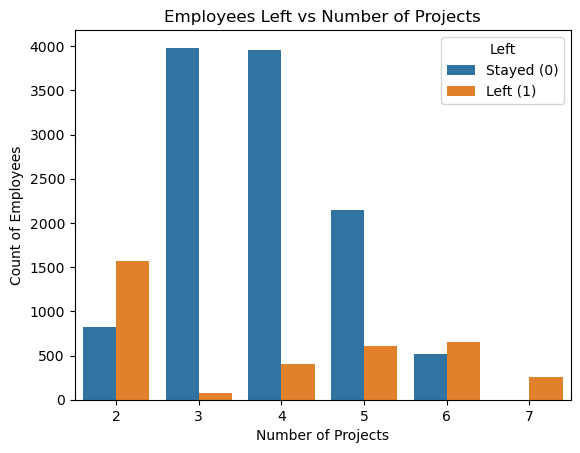

In [9]:
sns.countplot(x="numberOfProjects", hue="left", data=df)
plt.title("Employees Left vs Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Count of Employees")
plt.legend(title="Left", labels=["Stayed (0)", "Left (1)"])
plt.show()

In [ ]:
# Employees working on 2 projects have a high leaving rate
# Employees handling 3 and 4 projects mostly stayed in the company, showing better stability and balanced workload.
# As the number of projects increases to 5, 6, and 7, the number of employees leaving also increases.
# Employees with 7 projects almost entirely left the company, which may indicate work overload and stress

In [ ]:
# Find out the relationship between department and salary

salary       high   low  medium
dept                           
IT             83   609     535
RandD          51   364     372
accounting     74   358     335
hr             45   335     359
management    225   180     225
marketing      80   402     376
product_mng    68   451     383
sales         269  2099    1772
support       141  1146     942
technical     201  1372    1147
salary        high    low  medium
dept                             
IT            6.76  49.63   43.60
RandD         6.48  46.25   47.27
accounting    9.65  46.68   43.68
hr            6.09  45.33   48.58
management   35.71  28.57   35.71
marketing     9.32  46.85   43.82
product_mng   7.54  50.00   42.46
sales         6.50  50.70   42.80
support       6.33  51.41   42.26
technical     7.39  50.44   42.17


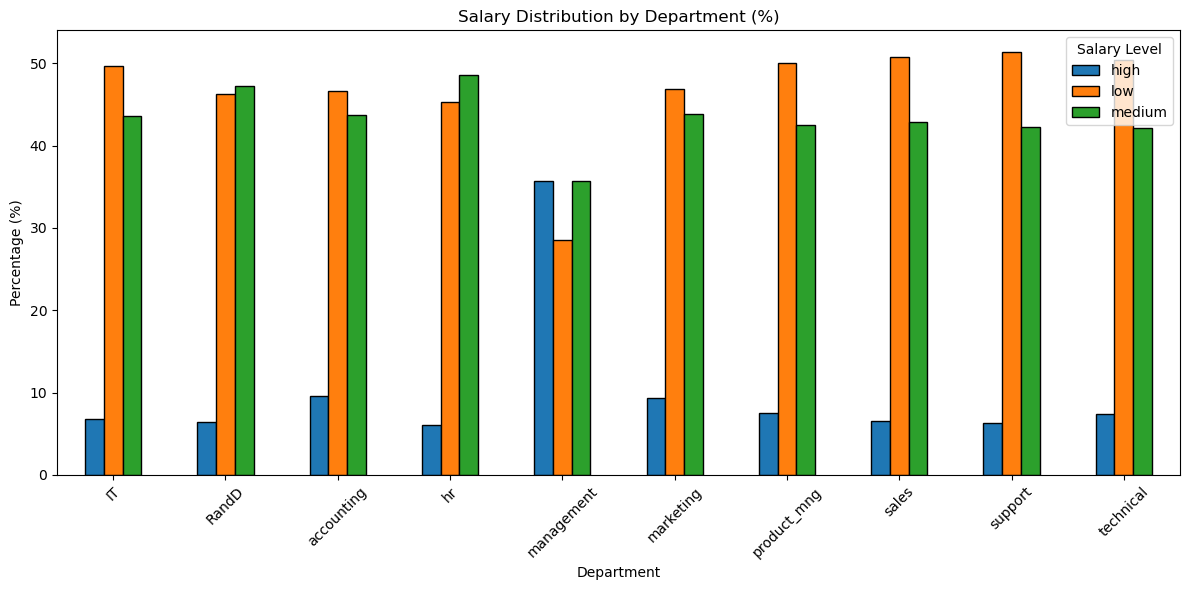

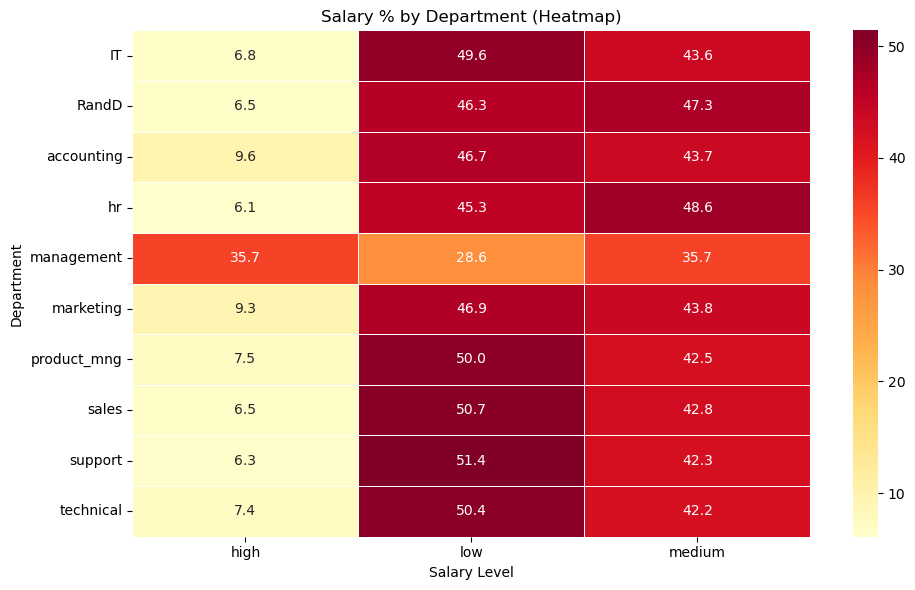

In [11]:
# Step 1 - crosstab shows count of each salary level per dept

salary_dept = pd.crosstab(df['dept'], df['salary'])
print(salary_dept)

# Step 2 - percentage view (more useful)
salary_dept_pct = pd.crosstab(df['dept'], df['salary'], normalize='index') * 100
print(salary_dept_pct.round(2))

# Step 3 - visualize it
salary_dept_pct.plot(kind='bar', figsize=(12, 6), edgecolor='black')

plt.title('Salary Distribution by Department (%)')
plt.xlabel('Department')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Salary Level')
plt.tight_layout()
plt.show()

# Step 4 - heatmap (cleaner view)
plt.figure(figsize=(10, 6))
sns.heatmap(salary_dept_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)

plt.title('Salary % by Department (Heatmap)')
plt.ylabel('Department')
plt.xlabel('Salary Level')
plt.tight_layout()
plt.show()

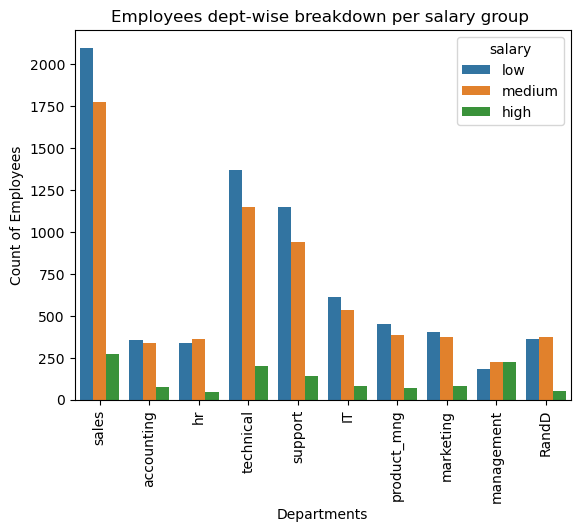

In [12]:
sns.countplot(df, x = 'dept', hue = 'salary')


plt.title("Employees dept-wise breakdown per salary group ")
plt.xlabel("Departments")
plt.ylabel("Count of Employees")
plt.xticks(rotation = 90)


plt.show()

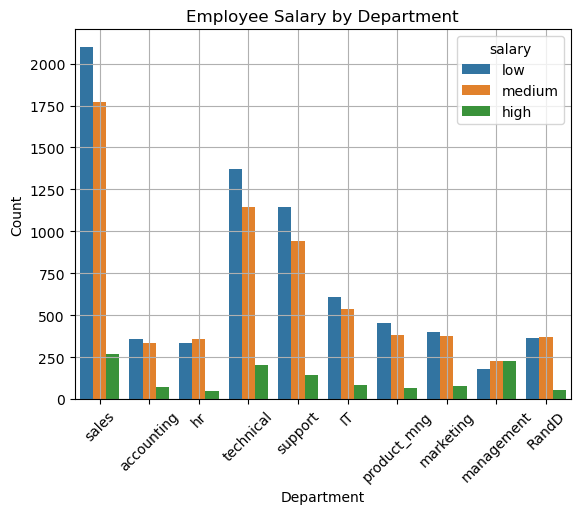

In [13]:
sns.countplot(data=df, x='dept', hue='salary')

plt.ylabel('Count')
plt.xlabel('Department')
plt.title('Employee Salary by Department')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Department strongly influences salary level.
# Employees in technical leadership roles (management, RandD) are better compensated,
# while customer-facing and support roles remain underpaid relative to company size.

In [ ]:
# Does the department play a role in employees leaving the company

# First, create a countplot
# create a pie plot - employee dist. by dept

# then , Create two subplots(pie)

# 1st pie plot - emp who left
# 2nd pie plot - emp who stayed
# 1 row , 2 col
# Give the conclusion

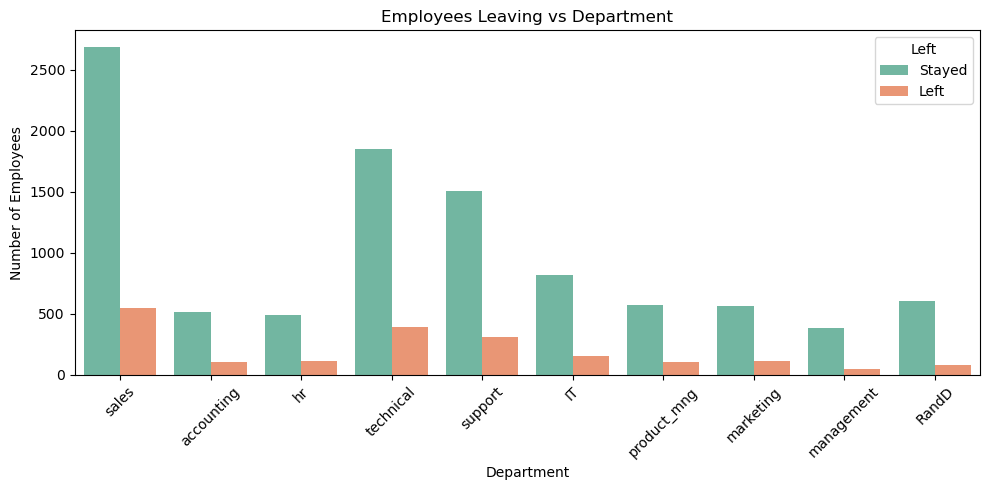

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x="dept", hue="left", data=df, palette="Set2")
plt.title("Employees Leaving vs Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.legend(title="Left", labels=["Stayed", "Left"])
plt.tight_layout()
plt.show()

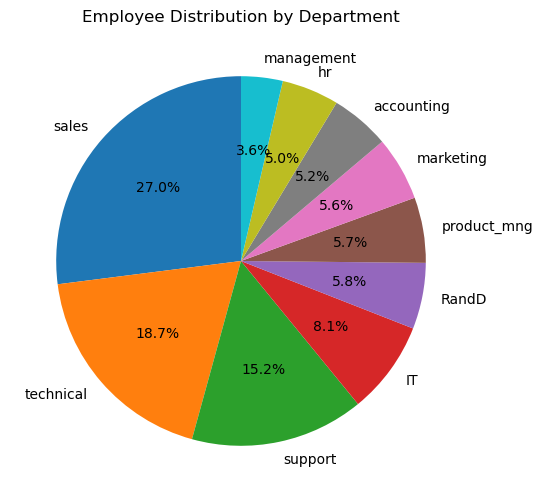

In [21]:
dept_counts = df['dept'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(dept_counts, labels=dept_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Employee Distribution by Department")
plt.show()

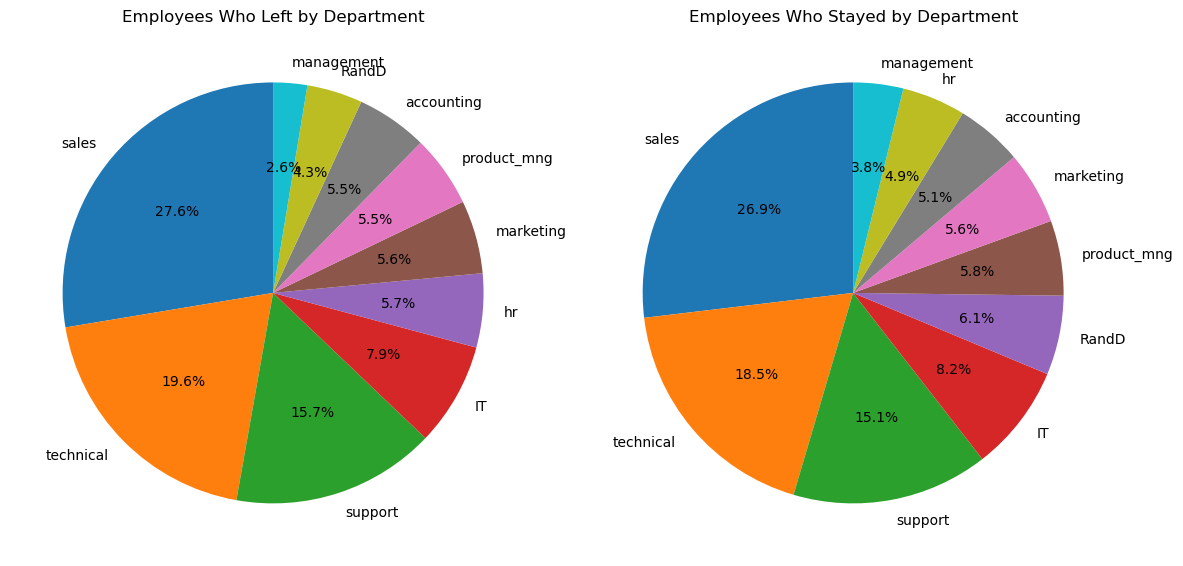

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

left_counts = df[df['left'] == 1]['dept'].value_counts()
axes[0].pie(left_counts, labels=left_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Employees Who Left by Department")

stay_counts = df[df['left'] == 0]['dept'].value_counts()
axes[1].pie(stay_counts, labels=stay_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Employees Who Stayed by Department")
plt.tight_layout()
plt.show()


In [ ]:
# Dept is not a imp factor for employees leaving the company

In [23]:
# Does the department play a role in employees leaving the company
# First, create a countplot
# Create subplots
# i want two pieplots
# 1st pie plot - employee dist. by dept
# 2nd pie plot - proportion of the employees who left dept wise
# 1 row , 2 col

sns.countplot(data = data, x='Department', hue='Left')
plt.ylabel('Left Company')
plt.xlabel('Department')
plt.title('Employee Left Company by Department')
plt.grid(True)
plt.show()



dept_counts = data['Department'].value_counts()


plt.pie(x=dept_counts,data=data,labels=dept_counts.index, autopct='%1.1f%%',shadow=True)
plt.title('Employee Department Counts')

# 1st pie plot - emp who left
# # 2nd pie plot - emp who stayed
# # 1 row , 2 col
# # Give the conclusion

fig = plt.subplots(1,2,figsize=(10,8))

left_counts = data[data['Left']==1]['Department'].value_counts()
stayed_counts = data[data['Left']==0]['Department'].value_counts()


plt.subplot(1,2,1)
plt.pie(x=left_counts,autopct='%1.1f%%',shadow=True, labels=left_counts)
plt.title('Employee Left Counts')



plt.subplot(1,2,2)
plt.pie(x=stayed_counts,autopct='%1.1f%%',shadow=True, labels=stayed_counts)
plt.title('Employee Stayed Counts')
plt.show()


NameError: name 'data' is not defined

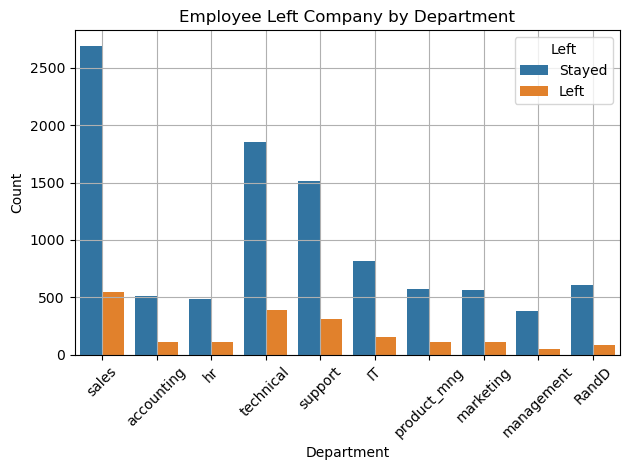

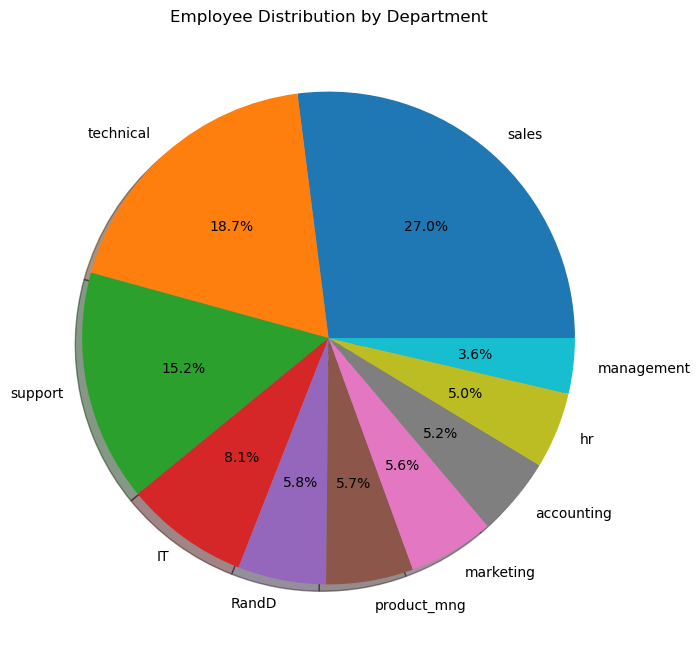

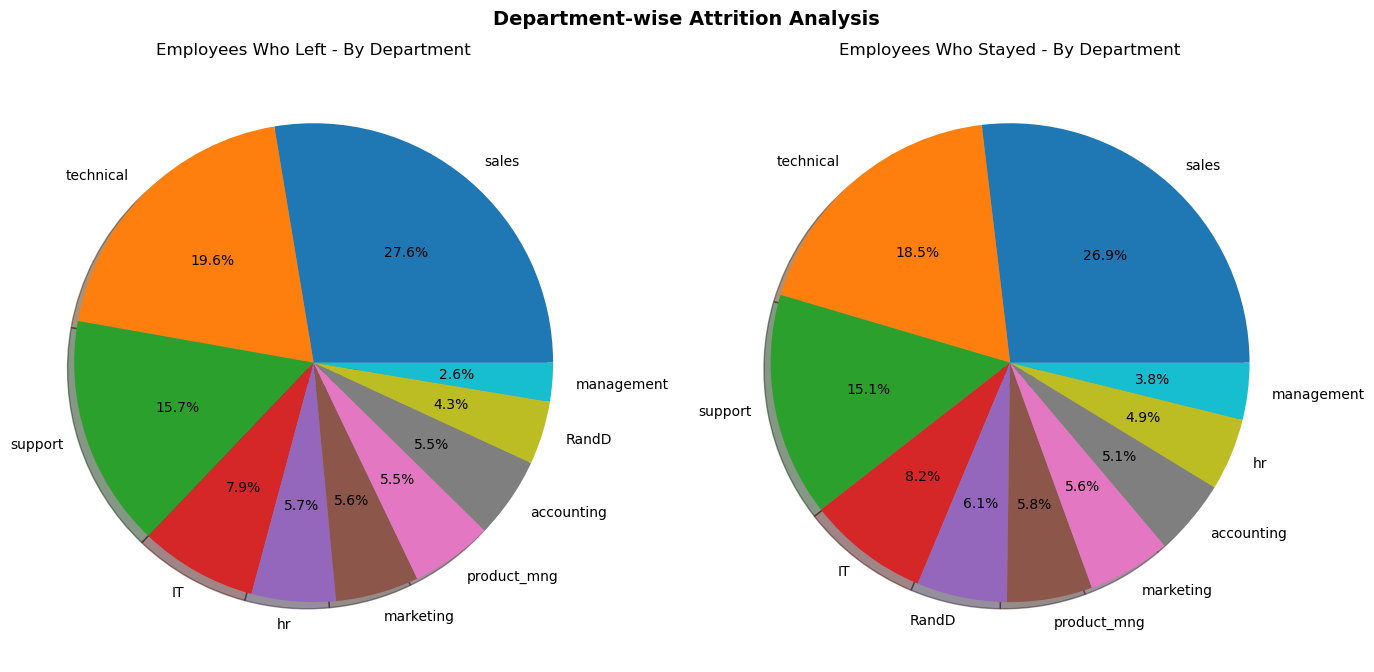

In [24]:
# Does the department play a role in employees leaving the company

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Countplot - Department vs Left
# ============================================================
sns.countplot(data=df, x='dept', hue='left')
plt.ylabel('Count')
plt.xlabel('Department')
plt.title('Employee Left Company by Department')
plt.xticks(rotation=45)
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Pie Plot - Employee Distribution by Department
# ============================================================
dept_counts = df['dept'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(x=dept_counts, labels=dept_counts.index, autopct='%1.1f%%', shadow=True)
plt.title('Employee Distribution by Department')
plt.show()

# ============================================================
# 3. Subplots - Who Left vs Who Stayed (dept wise)
# ============================================================
left_counts   = df[df['left'] == 1]['dept'].value_counts()
stayed_counts = df[df['left'] == 0]['dept'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.pie(x=left_counts, labels=left_counts.index, autopct='%1.1f%%', shadow=True)
plt.title('Employees Who Left - By Department')

plt.subplot(1, 2, 2)
plt.pie(x=stayed_counts, labels=stayed_counts.index, autopct='%1.1f%%', shadow=True)
plt.title('Employees Who Stayed - By Department')

plt.suptitle('Department-wise Attrition Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Extract atleast 3 more meaningful insights from the dataset
# salary , promotion

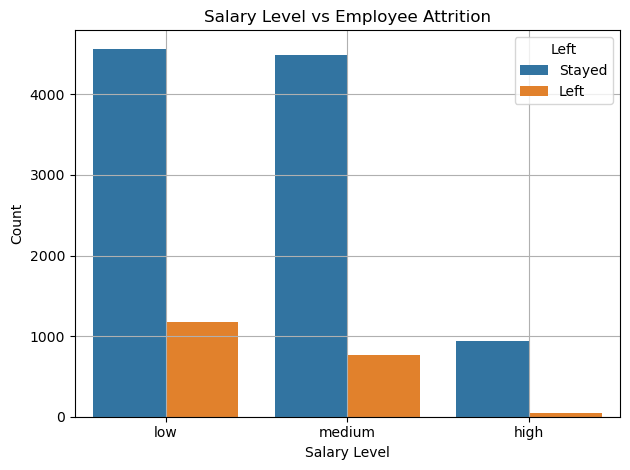

In [26]:
# ============================================================
# INSIGHT 1 - Salary vs Attrition (Did low salary cause leaving?)
# ============================================================
sns.countplot(data=df, x='salary', hue='left', order=['low', 'medium', 'high'])
plt.title('Salary Level vs Employee Attrition')
plt.xlabel('Salary Level')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.grid(True)
plt.tight_layout()
plt.show()

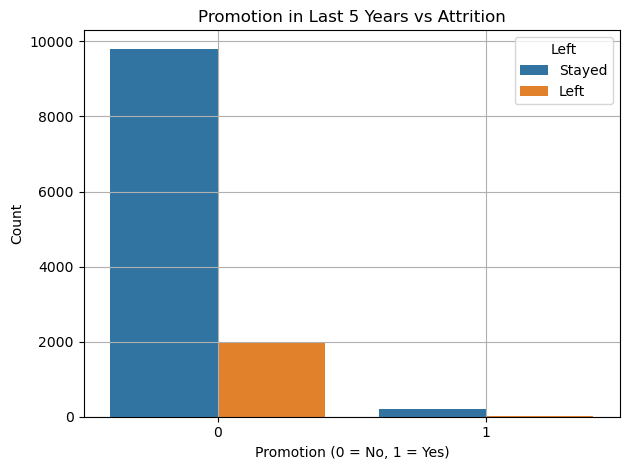

In [27]:
# ============================================================
# INSIGHT 2 - Promotion vs Attrition (Did lack of promotion cause leaving?)
# ============================================================
sns.countplot(data=df, x='promotionInLast5years', hue='left')
plt.title('Promotion in Last 5 Years vs Attrition')
plt.xlabel('Promotion (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.grid(True)
plt.tight_layout()
plt.show()

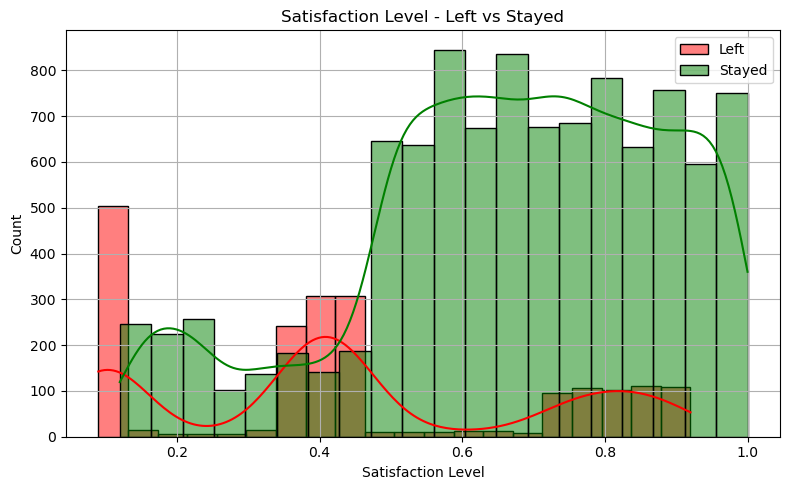

In [28]:
# ============================================================
# INSIGHT 3 - Satisfaction Level vs Attrition
# ============================================================
plt.figure(figsize=(8, 5))
sns.histplot(data=df[df['left'] == 1], x='satisfactoryLevel',
             color='red', label='Left', kde=True, bins=20)
sns.histplot(data=df[df['left'] == 0], x='satisfactoryLevel',
             color='green', label='Stayed', kde=True, bins=20)
plt.title('Satisfaction Level - Left vs Stayed')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

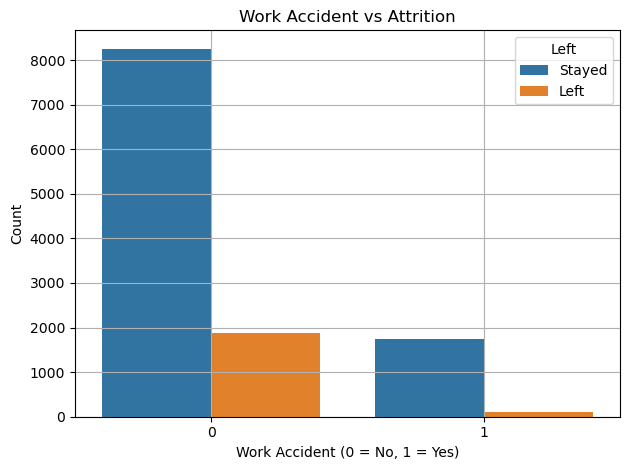

In [29]:
# ============================================================
# INSIGHT 4 - Work Accident vs Attrition
# ============================================================
sns.countplot(data=df, x='workAccident', hue='left')
plt.title('Work Accident vs Attrition')
plt.xlabel('Work Accident (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.grid(True)
plt.tight_layout()
plt.show()

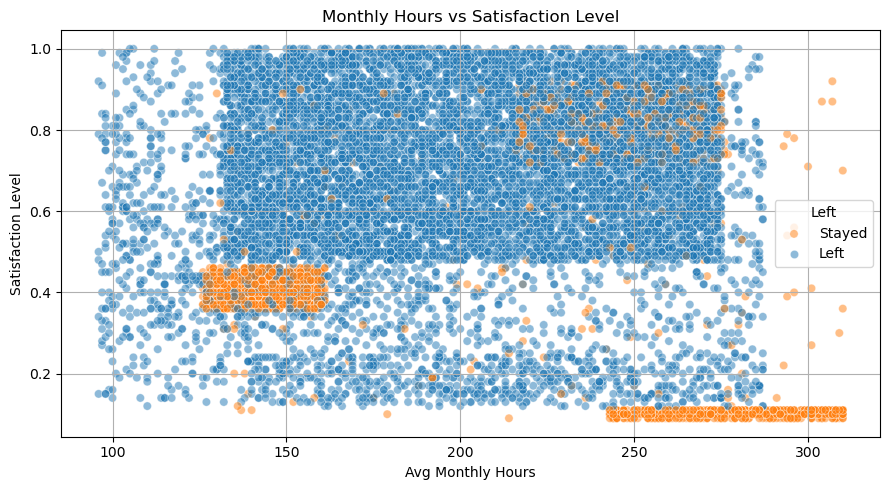

In [30]:
# ============================================================
# INSIGHT 5 - Avg Monthly Hours vs Satisfaction (colored by left)
# ============================================================
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='avgMonthlyHours', y='satisfactoryLevel',
                hue='left', alpha=0.5)
plt.title('Monthly Hours vs Satisfaction Level')
plt.xlabel('Avg Monthly Hours')
plt.ylabel('Satisfaction Level')
plt.legend(title='Left', labels=['Stayed', 'Left'])
plt.grid(True)
plt.tight_layout()
plt.show()